In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [15]:
data=pd.read_csv("BP dataset.csv")

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Num.                            219 non-null    int64  
 1   subject_ID                      219 non-null    int64  
 2   Sex(M/F)                        219 non-null    object 
 3   Age(year)                       219 non-null    int64  
 4   Height(cm)                      219 non-null    int64  
 5   Weight(kg)                      219 non-null    int64  
 6   Systolic Blood Pressure(mmHg)   219 non-null    int64  
 7   Diastolic Blood Pressure(mmHg)  219 non-null    int64  
 8   Heart Rate(b/m)                 219 non-null    int64  
 9   BMI(kg/m^2)                     219 non-null    float64
 10  Hypertension                    219 non-null    object 
 11  Diabetes                        38 non-null     object 
 12  cerebral infarction             20 n

In [19]:
data.isnull().sum()

Num.                                0
subject_ID                          0
Sex(M/F)                            0
Age(year)                           0
Height(cm)                          0
Weight(kg)                          0
Systolic Blood Pressure(mmHg)       0
Diastolic Blood Pressure(mmHg)      0
Heart Rate(b/m)                     0
BMI(kg/m^2)                         0
Hypertension                        0
Diabetes                          181
cerebral infarction               199
cerebrovascular disease           194
dtype: int64

In [21]:
data.isna().sum()

Num.                                0
subject_ID                          0
Sex(M/F)                            0
Age(year)                           0
Height(cm)                          0
Weight(kg)                          0
Systolic Blood Pressure(mmHg)       0
Diastolic Blood Pressure(mmHg)      0
Heart Rate(b/m)                     0
BMI(kg/m^2)                         0
Hypertension                        0
Diabetes                          181
cerebral infarction               199
cerebrovascular disease           194
dtype: int64

In [23]:
data.head(10)

,Num.,subject_ID,Sex(M/F),Age(year),Height(cm),Weight(kg),Systolic Blood Pressure(mmHg),Diastolic Blood Pressure(mmHg),Heart Rate(b/m),BMI(kg/m^2),Hypertension,Diabetes,cerebral infarction,cerebrovascular disease
0,1,2,Female,45,152,63,161,89,97,27.27,Stage 2 hypertension,NaN,NaN,NaN
1,2,3,Female,50,157,50,160,93,76,20.28,Stage 2 hypertension,NaN,NaN,NaN
2,3,6,Female,47,150,47,101,71,79,20.89,Normal,NaN,NaN,NaN
3,4,8,Male,45,172,65,136,93,87,21.97,Prehypertension,NaN,NaN,NaN
4,5,9,Female,46,155,65,123,73,73,27.06,Prehypertension,NaN,NaN,NaN
5,6,10,Female,48,160,68,124,62,70,26.56,Prehypertension,NaN,NaN,NaN
6,7,11,Female,48,153,49,126,78,84,20.93,Prehypertension,NaN,NaN,NaN
7,8,12,Female,53,160,70,108,73,84,27.34,Normal,NaN,NaN,NaN
8,9,13,Male,58,165,55,89,42,63,20.20,Normal,NaN,NaN,NaN
9,10,14,Female,47,150,47,98,56,69,20.89,Normal,NaN,NaN,NaN


In [27]:
cols=["Diabetes","cerebral infarction","cerebrovascular disease"]
data[cols]=data[cols].fillna(0)

In [37]:
count_htn=data["Hypertension"].value_counts()
count_htn

Hypertension
Prehypertension         85
Normal                  80
Stage 1 hypertension    34
Stage 2 hypertension    20
Name: count, dtype: int64

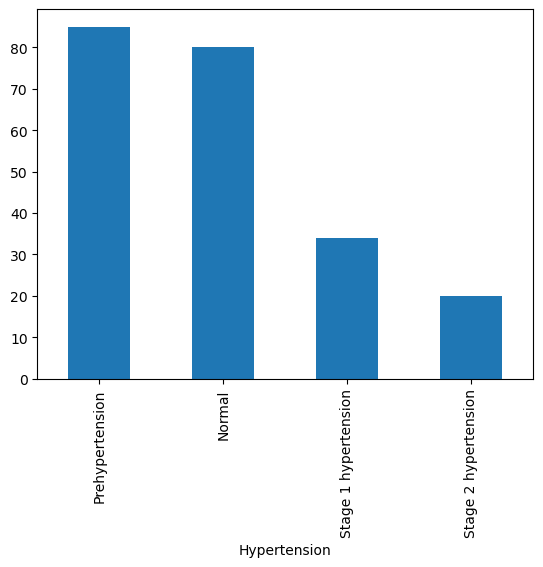

In [39]:
count_htn.plot(kind="bar")
plt.show()

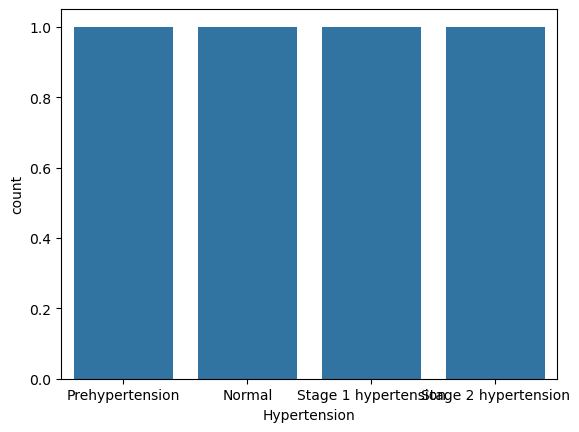

In [45]:
sns.countplot(count_htn)
plt.show()

In [49]:
data["Blood_Pressure"]=data["Systolic Blood Pressure(mmHg)"].astype(int).astype(str)+"/"+data["Diastolic Blood Pressure(mmHg)"].astype(int).astype(str)

In [51]:
data["Blood_Pressure"]

0      161/89
1      160/93
2      101/71
3      136/93
4      123/73
        ...  
214    111/70
215     93/57
216    120/69
217    106/69
218    108/68
Name: Blood_Pressure, Length: 219, dtype: object

In [59]:
data["risk_score"]=0
data.loc[data["Age(year)"]>=50,"risk_score"]+=1
data.loc[data["BMI(kg/m^2)"]>=25,"risk_score"]+=1
data.loc[data["Systolic Blood Pressure(mmHg)"]>=140,"risk_score"]+=1
data[["Age(year)","risk_score"]].head(10)

,Age(year),risk_score
0,45,2
1,50,2
2,47,0
3,45,0
4,46,1
5,48,1
6,48,0
7,53,2
8,58,1
9,47,0


In [63]:
data["risk_group"]=data["risk_score"].apply(
    lambda x:"high_risk" if x>=2 else "low_risk"
)

In [65]:
data["risk_group"].value_counts()

risk_group
low_risk     145
high_risk     74
Name: count, dtype: int64

In [131]:
htn_risgrp=pd.crosstab(data["Hypertension"],data["risk_group"])
htn_risgrp

risk_group,high_risk,low_risk
Hypertension,,
Normal,10,70
Prehypertension,12,73
Stage 1 hypertension,32,2
Stage 2 hypertension,20,0


In [133]:
risk_rate=(
    htn_risgrp[]/
    htn_risgrp.sum(axis=1)
    
)*100

In [135]:
risk_rate.round(2)

,Normal,Prehypertension,Stage 1 hypertension,Stage 2 hypertension,high_risk,low_risk
Hypertension,,,,,,
Normal,NaN,NaN,NaN,NaN,NaN,NaN
Prehypertension,NaN,NaN,NaN,NaN,NaN,NaN
Stage 1 hypertension,NaN,NaN,NaN,NaN,NaN,NaN
Stage 2 hypertension,NaN,NaN,NaN,NaN,NaN,NaN
